In [71]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [72]:
import matplotlib.pyplot as plt


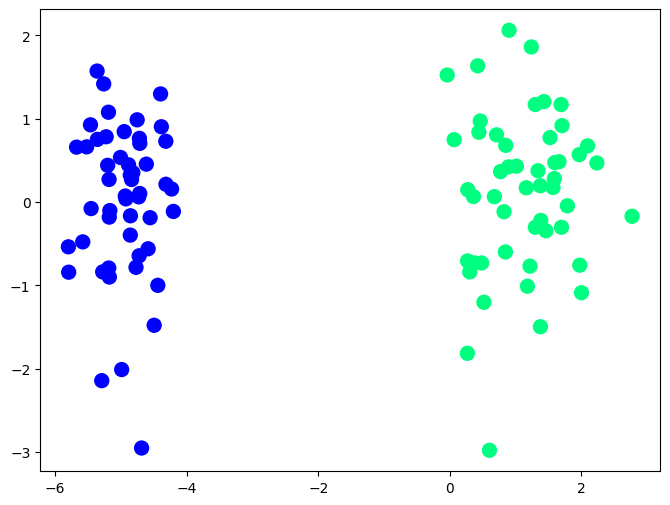

In [73]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter',s=100)

In [74]:
import numpy as np
def perceptron(X, y):
  X = np.insert(X,0,1,axis=1)
  weight = np.ones(X.shape[1])
  lr = 0.1
  for i in range(1000):
    j = np.random.randint(0,100)
    yhat = step(np.dot(X[j],weight))
    weight = weight + lr* yhat * X[j]
  return weight[0], weight[1:]

In [75]:
def step(z):
  return 1 if z >0 else 0

In [76]:
intercept_ , coef_ = perceptron(X, y)

In [77]:
print("Intercept_",intercept_)
print("Coef", coef_)

Intercept_ 51.800000000000466
Coef [55.70514048  4.48836935]


In [78]:
m = - (coef_[0]/coef_[1])
b = - (intercept_ / coef_[1])

In [79]:
x_input = np.linspace(-3,3,100)
y_input = m * x_input + b


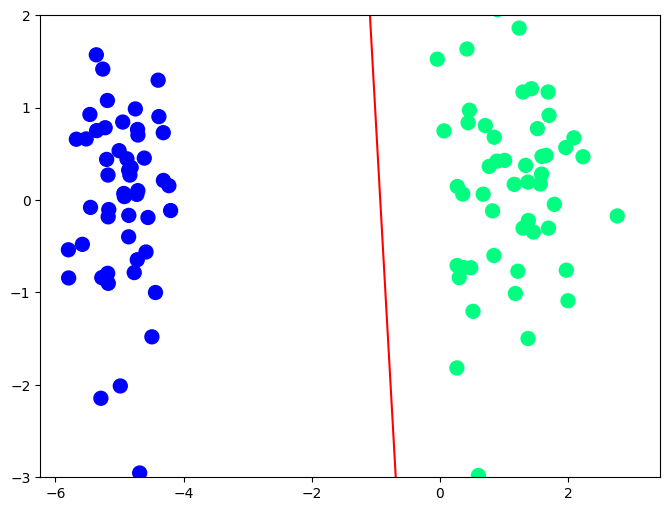

In [80]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y, cmap='winter', s=100)
plt.plot(x_input, y_input, color='red')
plt.ylim(-3,2)
plt.show()


In [81]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')

lor.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [82]:
lor.coef_

array([[3.68326256, 0.14732724]])

In [83]:
m = - (lor.coef_[0][0]/lor.coef_[0][1])
b = - (lor.intercept_ / lor.coef_[0][1])

In [84]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

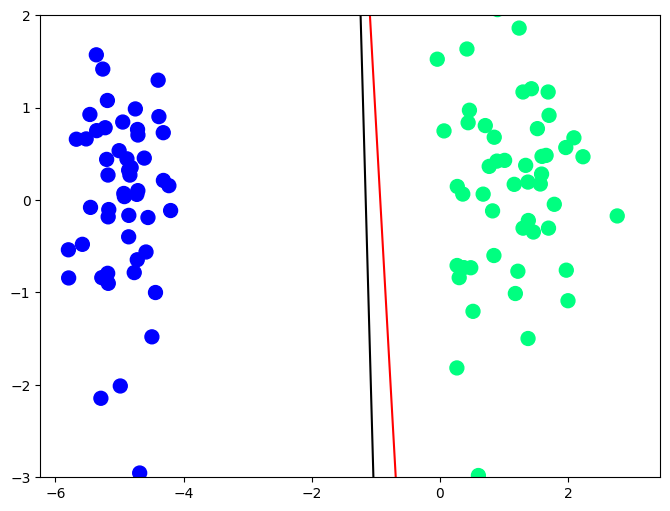

In [85]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y, cmap='winter', s=100)
plt.plot(x_input, y_input, color='red')
plt.plot(x_input1, y_input1, color='black')

plt.ylim(-3,2)
plt.show()

In [86]:
def perceptron(X, y):
  X = np.insert(X,0,1,axis=1)
  weight = np.ones(X.shape[1])
  lr = 0.25
  for i in range(1000):
    j = np.random.randint(0,100)
    yhat = sigmoid(np.dot(X[j],weight))
    weight = weight + lr* yhat * X[j]
  return weight[0], weight[1:]

In [87]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [88]:
intercept_ , coef_ = perceptron(X, y)

In [89]:
m = - (coef_[0]/coef_[1])
b = - (intercept_ / coef_[1])

In [90]:

x_input3 = np.linspace(-3,3,100)
y_input3 = m * x_input + b

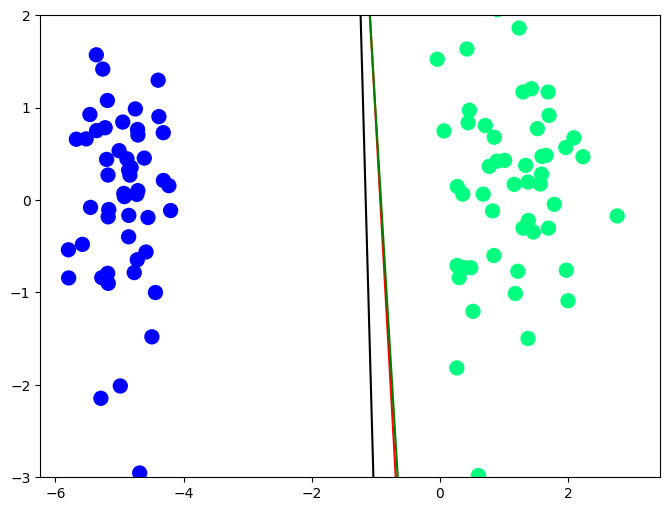

In [91]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y, cmap='winter', s=100)
plt.plot(x_input, y_input, color='red')
plt.plot(x_input1, y_input1, color='black')

plt.plot(x_input3, y_input3, color='green')
plt.ylim(-3,2)
plt.show()

In [100]:
# def gd(X, y):
#     X = np.insert(X, 0, 1, axis=1)
#     weight = np.ones(X.shape[1])
#     lr = 0.1

#     for i in range(2500):
#         y_hat = sigmoid(np.dot(X, weight))
#         # FIXED: Pass both arguments into np.dot and transpose X
#         gradient = np.dot(X.T, (y - y_hat)) / X.shape[0]
#         weight = weight + (lr * gradient)

#     return weight[0], weight[1:]

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gd(X, y):
    X = np.insert(X, 0, 1, axis=1)
    weight = np.ones(X.shape[1])
    lr = 0.1

    for i in range(2500):
        y_hat = sigmoid(np.dot(X, weight))
        # FIXED: Changed subtraction order to (y_hat - y) to match standard minimizing step
        gradient = np.dot(X.T, (y_hat - y)) / X.shape[0]
        # FIXED: Subtract the gradient to move downwards toward minimum loss
        weight = weight - (lr * gradient)

    return weight[0], weight[1:]


In [101]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [102]:
# intercept_, coef_ = gd(X,y)
intercept_, coef_ = gd(X, y)

m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

x_input4 = np.linspace(-3, 3, 100)
# FIXED: Changed x_input to x_input4 so it calculates using the correct range
y_input4 = m * x_input4 + b


In [103]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [104]:
x_input4 = np.linspace(-3,3,100)
y_input4 = m * x_input4 + b

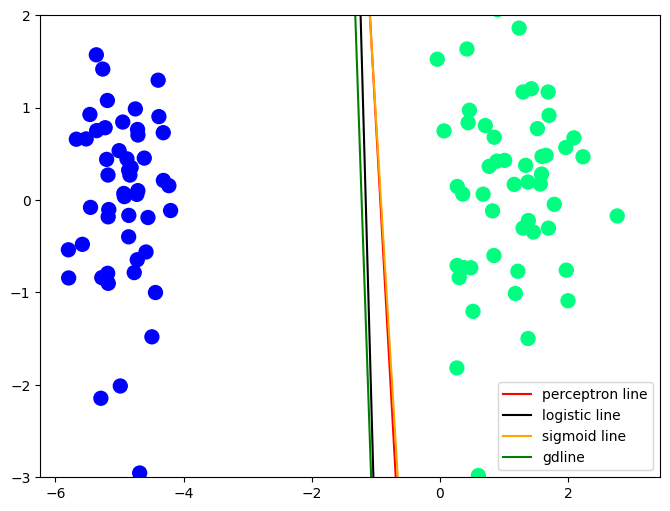

In [105]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y, cmap='winter', s=100)
plt.plot(x_input, y_input, color='red', label='perceptron line')
plt.plot(x_input1, y_input1, color='black',label='logistic line')

plt.plot(x_input3, y_input3, color='orange', label='sigmoid line')
plt.plot(x_input4, y_input4, color='green', label='gdline')

plt.ylim(-3,2)
plt.legend()
plt.show()

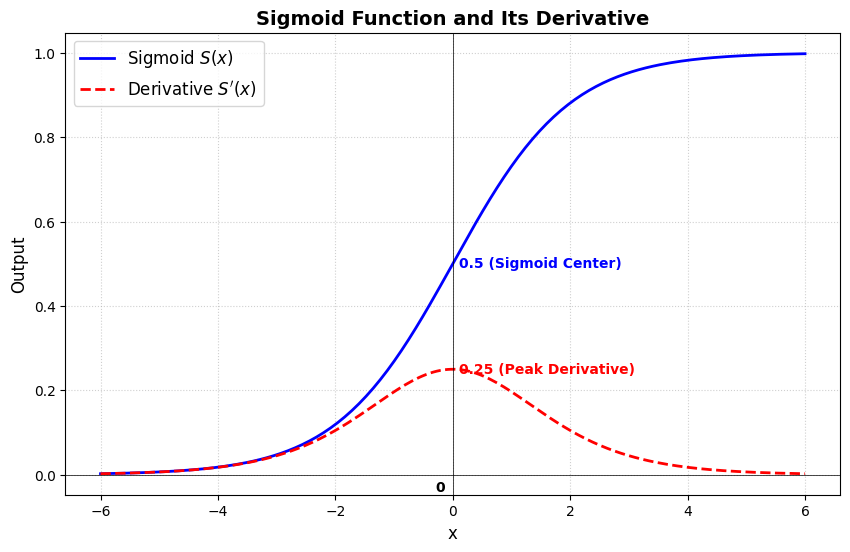

In [98]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    """Compute the sigmoid function."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Compute the derivative of the sigmoid function."""
    s = sigmoid(x)
    return s * (1 - s)

# Generate 200 evenly spaced points between -6 and 6
x = np.linspace(-6, 6, 200)

# Compute values
y_sigmoid = sigmoid(x)
y_derivative = sigmoid_derivative(x)

# Setup the plot
plt.figure(figsize=(10, 6))

# Plot Sigmoid
plt.plot(x, y_sigmoid, label="Sigmoid $S(x)$", color="blue", linewidth=2)

# Plot Derivative
plt.plot(x, y_derivative, label="Derivative $S'(x)$", color="red", linewidth=2, linestyle="--")

# Format chart elements
plt.title("Sigmoid Function and Its Derivative", fontsize=14, fontweight="bold")
plt.xlabel("x", fontsize=12)
plt.ylabel("Output", fontsize=12)

# Center lines (Axes)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)

# Add numbers/labels at the center intersections
plt.text(0.1, 0.5, '0.5 (Sigmoid Center)', fontsize=10, color='blue', fontweight='bold', va='center')
plt.text(0.1, 0.25, '0.25 (Peak Derivative)', fontsize=10, color='red', fontweight='bold', va='center')
plt.text(-0.3, -0.04, '0', fontsize=10, color='black', fontweight='bold')

plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=12)

# Show the plot
plt.show()


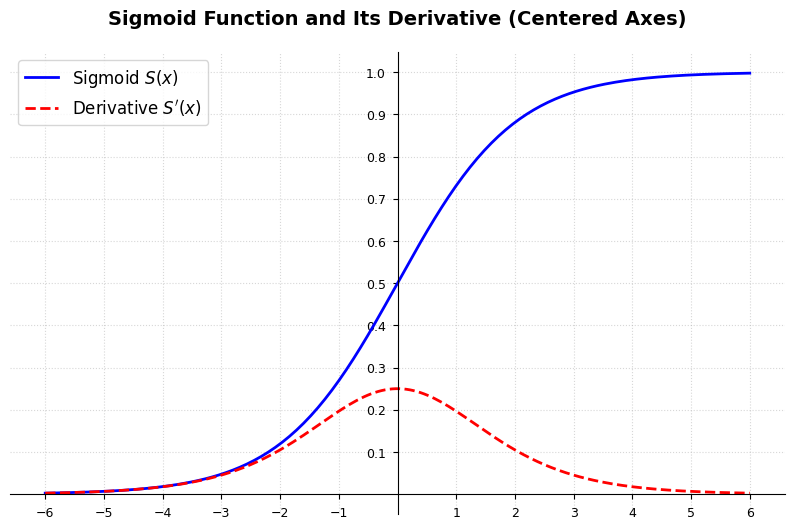

In [99]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    """Compute the sigmoid function."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Compute the derivative of the sigmoid function."""
    s = sigmoid(x)
    return s * (1 - s)

# Generate 200 evenly spaced points between -6 and 6
x = np.linspace(-6, 6, 200)

# Compute values
y_sigmoid = sigmoid(x)
y_derivative = sigmoid_derivative(x)

# Setup the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Sigmoid and Derivative
ax.plot(x, y_sigmoid, label="Sigmoid $S(x)$", color="blue", linewidth=2)
ax.plot(x, y_derivative, label="Derivative $S'(x)$", color="red", linewidth=2, linestyle="--")

# Move the left and bottom spines (axes borders) to the center lines
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

# Hide the top and right spines (outer borders)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Define custom ticks: X from -6 to 6, Y from 0 to 1 with 0.1 intervals
ax.set_xticks([-6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6])
ax.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# Adjust tick label placement so they sit cleanly next to the center lines
ax.xaxis.set_tick_params(labelsize=9, pad=5)
ax.yaxis.set_tick_params(labelsize=9, pad=5)

# Format chart elements
plt.title("Sigmoid Function and Its Derivative (Centered Axes)", fontsize=14, fontweight="bold", pad=20)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)

# Show the plot
plt.show()
